In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import random
from qiskit import Aer, QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.opflow import PauliSumOp, PauliExpectation, CircuitSampler, StateFn
from qiskit.utils import QuantumInstance
from qiskit.algorithms.optimizers import SPSA
from qiskit.algorithms import NumPyMinimumEigensolver
import pygad  # For the genetic algorithm
#from multiprocessing import Process, Manager
import multiprocessing
from qiskit import transpile
import copy
import json

import warnings
warnings.filterwarnings("ignore")


from qiskit.converters import circuit_to_dag, dag_to_circuit
from qiskit import QuantumCircuit
import numpy as np
import stim

def transform_to_allowed_gates(circuit, **kwargs):
    """
    circuit (QuantumCircuit): Circuit with only Clifford gates (1q rotations Ry, Rz must be k*pi/2).
    kwargs (Dict): All the arguments that need to be passed on to the next function calls.
    
    Returns:
    (QuantumCircuit) Logically equivalent circuit but with gates in required format (no Ry, Rz gates; only S, Sdg, H, X, Z).
    """
    dag = circuit_to_dag(circuit)
    threshold = 1e-3
    # we will substitute nodes inplace
    for node in dag.op_nodes():
        if node.name == "ry":
            angle = float(node.op.params[0])
            # substitute gates
            if abs(angle - 0) < threshold:
                dag.remove_op_node(node)
            elif abs(angle - np.pi/2) < threshold:
                qc_loc = QuantumCircuit(1)
                qc_loc.sdg(0)
                qc_loc.sx(0)
                qc_loc.s(0)
                qc_loc_instr = qc_loc.to_instruction()
                dag.substitute_node(node, qc_loc_instr, inplace = True)
            elif abs(angle - np.pi) < threshold:
                qc_loc = QuantumCircuit(1)
                qc_loc.y(0)
                qc_loc_instr = qc_loc.to_instruction()
                dag.substitute_node(node, qc_loc_instr, inplace=True)
            elif abs(angle - 1.5*np.pi) < threshold:
                qc_loc = QuantumCircuit(1)
                qc_loc.sdg(0)
                qc_loc.sxdg(0)
                qc_loc.s(0)
                qc_loc_instr = qc_loc.to_instruction()
                dag.substitute_node(node, qc_loc_instr, inplace = True)
        elif node.name == 'rz':
            angle = float(node.op.params[0])
            #substitute gates
            if abs(angle - 0) < threshold:
                dag.remove_op_node(node)
            elif abs(angle - np.pi/2) < threshold:
                qc_loc = QuantumCircuit(1)
                qc_loc.s(0)
                qc_loc_instr = qc_loc.to_instruction()
                dag.substitute_node(node, qc_loc_instr, inplace=True)
            elif abs(angle - np.pi) < threshold:
                qc_loc = QuantumCircuit(1)
                qc_loc.z(0)
                qc_loc_instr = qc_loc.to_instruction()
                dag.substitute_node(node, qc_loc_instr, inplace=True)
            elif abs(angle - 1.5*np.pi) < threshold:
                qc_loc = QuantumCircuit(1)
                qc_loc.sdg(0)
                qc_loc_instr = qc_loc.to_instruction()
                dag.substitute_node(node, qc_loc_instr, inplace=True)
        elif node.name == "x":
            qc_loc = QuantumCircuit(1)
            qc_loc.x(0)
            qc_loc_instr = qc_loc.to_instruction()
            dag.substitute_node(node, qc_loc_instr, inplace=True)
    return dag_to_circuit(dag)#.decompose()

def qiskit_to_stim(circuit):
    """
    Transform Qiskit QuantumCircuit into stim circuit.
    circuit (QuantumCircuit): Clifford-only circuit.

    Returns:
    (stim._stim_sse2.Circuit) stim circuit.
    """
    assert isinstance(circuit, QuantumCircuit), f"Circuit is not a Qiskit QuantumCircuit."
    allowed_gates = ["X", "Y", "Z", "H", "CX", "S", "S_DAG", "SQRT_X", "SQRT_X_DAG"]
    stim_circ = stim.Circuit()
    # make sure right number of qubits in stim circ
    for i in range(circuit.num_qubits):
        stim_circ.append("I", [i])
    for instruction in circuit:
        gate_lbl = instruction.operation.name.upper()
        if gate_lbl == "BARRIER":
            continue
        elif gate_lbl == "SDG":
            gate_lbl = "S_DAG"
        elif gate_lbl == "SX":
            gate_lbl = "SQRT_X"
        elif gate_lbl == "SXDG":
            gate_lbl = "SQRT_X_DAG"
        assert gate_lbl in allowed_gates, f"Invalid gate {gate_lbl}."
        qubit_idc = [qb.index for qb in instruction.qubits]
        stim_circ.append(gate_lbl, qubit_idc)
    return stim_circ






# Function to log output to a file
def log_to_file(message, filename="output"):
    full_file = filename + ".txt"
    with open(filename, "a") as f:
        f.write(f"{message}\n")

# Function to generate a random graph and save it to a file
def generate_random_graph(num_vertices, edge_prob=0.5, weighted=False, save_path=None):
    G = nx.Graph()
    G.add_nodes_from(range(num_vertices))
    
    for i in range(num_vertices):
        for j in range(i + 1, num_vertices):
            if random.random() < edge_prob:
                weight = random.randint(1, 10) if weighted else 1
                G.add_edge(i, j, weight=weight)
    
    # Optionally save the graph
    if save_path:
        # Convert graph to dictionary format
        graph_dict = {
            "nodes": list(G.nodes),
            "edges": [
                {"source": i, "target": j, "weight": w['weight']}
                for i, j, w in G.edges(data=True)
            ]
        }
        with open(save_path+".json", "w") as f:
            json.dump(graph_dict, f)
    
    return G

# Function to load a graph from a saved file
def load_graph(save_path):
    with open(save_path+".json", "r") as f:
        graph_data = json.load(f)
    
    G = nx.Graph()
    G.add_nodes_from(graph_data["nodes"])
    for edge in graph_data["edges"]:
        G.add_edge(edge["source"], edge["target"], weight=edge["weight"])
    
    return G


# # Function to create the cost Hamiltonian
# def create_cost_hamiltonian(G):
#     terms = []
#     for i, j, w in G.edges(data='weight'):
#         weight = w if w is not None else 1
#         terms.append(weight * PauliSumOp.from_list([(f"ZZ", weight)]))
#     print(sum(terms))
#     return sum(terms)

def create_cost_hamiltonian(G):
    terms = []
    for i, j, w in G.edges(data='weight'):
        weight = w if w is not None else 1
        
        # Create a Pauli string with 'I' for all qubits except 'Z' on qubits i and j
        num_qubits = G.number_of_nodes()
        pauli_string = ['I'] * num_qubits
        pauli_string[i] = 'Z'
        pauli_string[j] = 'Z'
        
        # Convert the Pauli string to the format expected by PauliSumOp
        terms.append(PauliSumOp.from_list([("".join(pauli_string), weight)]))
    
    # Sum all the terms to create the Hamiltonian
    hamiltonian = sum(terms)
    print(hamiltonian)
    return hamiltonian


def create_cost_hamiltonian_stim(G):
    coeffs = []
    paulis = []

    for i, j, w in G.edges(data='weight'):
        weight = w if w is not None else 1
        # Store the weight (coefficient) in coeffs
        coeffs.append(weight)
        
        # Create the Pauli term in string format for ZZ on qubits i and j
        pauli_term = ['I'] * G.number_of_nodes()  # Initialize as identity on all qubits
        pauli_term[i] = 'Z'  # Z on the first qubit of the edge
        pauli_term[j] = 'Z'  # Z on the second qubit of the edge
        paulis.append(''.join(pauli_term))  # Join into a single string
    print (coeffs, paulis)
    return coeffs, paulis


# Function to build the QAOA circuit
def multi_angle_qaoa_circuit(gamma_params, beta_params, num_qubits, G):
    qc = QuantumCircuit(num_qubits)
    qc.h(range(num_qubits))

    for idx, (i, j) in enumerate(G.edges):
        gamma = gamma_params[idx]  # Get the gamma parameter
        qc.cx(i, j)
        qc.rz(-2 * gamma, j)
        qc.cx(i, j)

    for idx, i in enumerate(G.nodes):
        beta = beta_params[idx]  # Get the beta parameter
        qc.rx(2 * beta, i)
    
    return qc


import numpy as np
from qiskit import QuantumCircuit

def modify_circuit(circuit: QuantumCircuit) -> QuantumCircuit:
    # Step 1: Transpile the circuit to use Clifford + Rz gates
    transpiled_circuit = transpile(circuit, basis_gates=['rz', 's', 'sx', 'cx', 'h'])

    # Step 2: Create a new circuit to store the modified version
    modified_circuit = QuantumCircuit(transpiled_circuit.num_qubits)

    # Step 3: Iterate through the gates in the transpiled circuit
    for instr in transpiled_circuit.data:
        gate = instr[0]
        qubits = instr[1]

        # Handle the specified Rz modifications
        if gate.name == 'rz':
            angle = gate.params[0]
            if angle == -np.pi or angle == np.pi:
                # Replace "rz(-pi)" or "rz(pi)" with "z"
                modified_circuit.z(*qubits)
            elif angle == -np.pi / 2 or angle == 3 * np.pi / 2:
                # Replace "rz(-pi/2)" or "rz(3*pi/2)" with "s" followed by "z"
                modified_circuit.s(*qubits)
                modified_circuit.z(*qubits)
            elif angle == -3 * np.pi / 2 or angle == np.pi / 2:
                # Replace "rz(-3*pi/2)" or "rz(pi/2)" with "s"
                modified_circuit.s(*qubits)
            else:
                # Add the Rz gate if it does not match any modification
                modified_circuit.append(gate, qubits)
        else:
            # Add the gate to the modified circuit if it's not an Rz gate
            modified_circuit.append(gate, qubits)

    return modified_circuit


    return batch_fitness    

    #keeping this in case parallel doesnt work - but this is not in use
#     def fitness_function(ga_instance, solution, solution_idx):
#         # Convert integer solution to angles
#         restricted_params = [param * (np.pi / 4) for param in solution]
#         param_dict = dict(zip(gamma_params + beta_params, restricted_params))
#         qaoa_circuit = multi_angle_qaoa_circuit(gamma_params, beta_params, num_qubits, G)
#         qaoa_circuit = qaoa_circuit.bind_parameters(param_dict)
        


# Two-step QAOA implementation with PyGAD in Step 1
def run_two_step_qaoa(num_vertices=5, edge_prob=0.5, weighted=False,save_path=None,repro=0):
    #save_path+="_"+str(repro)
    if(repro==0):
        G = generate_random_graph(num_vertices, edge_prob, weighted,save_path)
    else:
        G = load_graph(save_path)
    num_qubits = len(G.nodes)
    plt.figure(figsize=(6, 6))
    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_color="lightblue", node_size=700)
    if weighted:
        edge_labels = {(i, j): G[i][j]['weight'] for i, j in G.edges}
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
    plt.title("Generated Random Graph for QAOA")
    plt.show()
    
    cost_hamiltonian = create_cost_hamiltonian(G)
    coeffs,paulis = create_cost_hamiltonian_stim(G)
    gamma_params = [Parameter(f'gamma_{i}_{j}') for i, j in G.edges]
    beta_params = [Parameter(f'beta_{i}') for i in G.nodes]

    #quantum_instance = QuantumInstance(Aer.get_backend('qasm_simulator'))
    #quantum_instance_stab = QuantumInstance(Aer.get_backend('aer_simulator_stabilizer'))
    #sampler = CircuitSampler(quantum_instance) 
    #sampler_stab = CircuitSampler(quantum_instance_stab)

    sim = stim.TableauSimulator()

    # To capture expectation values for both steps
    expectation_values_step1 = []
    expectation_values_step2 = []
    

    def process_data(solution,i,result_queue):
        #lst_sol = list(solution) - not sure if this is needed
        # Convert integer solution to angles
        restricted_params = [param * (np.pi / 4) for param in solution]
        param_dict = dict(zip(gamma_params + beta_params, restricted_params))
        qaoa_circuit_pre = multi_angle_qaoa_circuit(gamma_params, beta_params, num_qubits, G)
        qaoa_circuit_pre = qaoa_circuit_pre.bind_parameters(param_dict)
        
        ###########
        qaoa_circuit_pre2 = modify_circuit(qaoa_circuit_pre) #transpile(qaoa_circuit_pre, basis_gates=['rz', 'rx', 'cx', 'h'])
        #print("pre2: ", qaoa_circuit_pre2)
        #qaoa_circuit = transform_to_allowed_gates(qaoa_circuit_pre2)
        #print("post transform: ", qaoa_circuit)
        stim_qc = qiskit_to_stim(qaoa_circuit)
        sim.do_circuit(stim_qc)
        pauli_expect = [sim.peek_observable_expectation(stim.PauliString(p)) for p in paulis] #need paulis
        loss = np.dot(coeffs, pauli_expect) #need coeffs
        expectation = loss #this is what the return function requires
        ############
        
        #qaoa_circuit = modify_circuit(qaoa_circuit_pre)
        #state = StateFn(qaoa_circuit)
        #observable = PauliExpectation().convert(StateFn(cost_hamiltonian, is_measurement=True) @ state)
        #expectation = sampler_stab.convert(observable).eval().real
        
        result_queue.put(((-1*expectation),i))  
    
    
    def fitness_function_batch(ga_instance, solutions, solution_idx):
        total_iterations = len(solutions)
        num_processes = len(solutions) #TODO
        chunk_size = total_iterations // num_processes
        processes = []
        result_queue = multiprocessing.Queue()

        for i in range(num_processes):
            process = multiprocessing.Process(target=process_data, args=(solutions[i],i,result_queue))
            processes.append(process)
            process.start()

        for process in processes:
            process.join()

        # Gather and aggregate results if necessary
        batch_fitness=[0]*len(solutions)
        while not result_queue.empty():
            item=result_queue.get()
            #print("item:",item)
            batch_fitness[item[1]]=item[0]
        for i in range(len(batch_fitness)):
            expectation_values_step1.append(batch_fitness[i])
        return batch_fitness    

    #keeping this in case parallel doesnt work - but this is not in use
#     def fitness_function(ga_instance, solution, solution_idx):
#         # Convert integer solution to angles
#         restricted_params = [param * (np.pi / 4) for param in solution]
#         param_dict = dict(zip(gamma_params + beta_params, restricted_params))
#         qaoa_circuit = multi_angle_qaoa_circuit(gamma_params, beta_params, num_qubits, G)
#         qaoa_circuit = qaoa_circuit.bind_parameters(param_dict)
        
#         state = StateFn(qaoa_circuit)
#         observable = PauliExpectation().convert(StateFn(cost_hamiltonian, is_measurement=True) @ state)
#         expectation = sampler.convert(observable).eval().real
#         expectation_values_step1.append(expectation)
#         return -expectation  # Maximize fitness by minimizing expectation

    # PyGAD setup
    num_params = len(gamma_params) + len(beta_params)
    log_to_file(f"Num params: {len(gamma_params) + len(beta_params)}",save_path)
    GENERATION=1000#0
    PARENTS_MATING=50#20
    POP_SIZE=50
    ga_instance = pygad.GA(
        num_generations=GENERATION,
        num_parents_mating=PARENTS_MATING,
        fitness_func=fitness_function_batch, # = fitness_function for single thread
        sol_per_pop=POP_SIZE,
        num_genes=num_params,
        gene_type=int,
        init_range_low=0,
        init_range_high=3,  # Choose from 0, 1, 2, 3
        mutation_percent_genes=10,
        mutation_type="random",
        parent_selection_type="tournament",
        keep_parents=-1,
        crossover_type="single_point",
        crossover_probability=0.9,
        keep_elitism=10,
        fitness_batch_size=POP_SIZE
    )

    ga_instance.run()
    solution, solution_fitness, _ = ga_instance.best_solution()
    params_after_step1 = [param * (np.pi / 4) for param in solution]  # Convert back to angles
    final_energy_step1 = -solution_fitness  # Negate to get final energy value

    # Print optimal parameters and expectation value after Step 1
    #print("\nOptimized Parameters after Step 1:", params_after_step1)
    #print("Final QAOA Energy after Step 1:", final_energy_step1)
    log_to_file(f"\nOptimized Parameters after Step 1: {params_after_step1}",save_path)
    log_to_file(f"Final QAOA Energy after Step 1: {final_energy_step1}",save_path)


    # Step 2: Full optimization with SPSA optimizer
    def unrestricted_expectation_value(params):
        param_dict = dict(zip(gamma_params + beta_params, params))
        qaoa_circuit = multi_angle_qaoa_circuit(gamma_params, beta_params, num_qubits, G)
        qaoa_circuit = qaoa_circuit.bind_parameters(param_dict)
        
        state = StateFn(qaoa_circuit)
        observable = PauliExpectation().convert(StateFn(cost_hamiltonian, is_measurement=True) @ state)
        expectation = sampler.convert(observable).eval().real
        expectation_values_step2.append(expectation)
        return expectation

#     # Run Step 2 with SPSA, starting from the parameters obtained in Step 1
#     spsa = SPSA(maxiter=1000)
#     result_step2 = spsa.optimize(num_params, unrestricted_expectation_value, initial_point=params_after_step1)
#     final_optimal_params = result_step2[0]  # Access optimized parameters as first element of the tuple
#     final_energy_step2 = expectation_values_step2[-1]

#     # Print final optimized parameters and energy after Step 2
#     print("\nOptimized Parameters after Step 2:", final_optimal_params)
#    print("Final QAOA Energy after Step 2:", final_energy_step2)

    # Solve with classical Eigensolver for comparison
    eigensolver = NumPyMinimumEigensolver()
    exact_solution = eigensolver.compute_minimum_eigenvalue(cost_hamiltonian).eigenvalue.real
    #print("Exact Energy from Eigensolver:", exact_solution)
    log_to_file(f"Exact Energy from Eigensolver: {exact_solution}",save_path)

    # # Plotting the expectation values for both steps
    # plt.figure(figsize=(12, 6))
    # plt.plot(expectation_values_step1, marker='o', label="Step 1: Genetic Algorithm")
    # #plt.plot(range(len(expectation_values_step1), len(expectation_values_step1) + len(expectation_values_step2)), expectation_values_step2, marker='o', color='r', label="Step 2: SPSA")
    # plt.title('Expectation Values Over Iterations')
    # plt.xlabel('Iteration')
    # plt.ylabel('Expectation Value (Energy)')
    # plt.legend()
    # plt.grid()
    # plt.show()

/var/tmp/ipykernel_2671867/2519150318.py:7: DeprecationWarning: The ``qiskit.opflow`` module is deprecated as of qiskit-terra 0.24.0. It will be removed no earlier than 3 months after the release date. For code migration guidelines, visit https://qisk.it/opflow_migration.
  from qiskit.opflow import PauliSumOp, PauliExpectation, CircuitSampler, StateFn


0


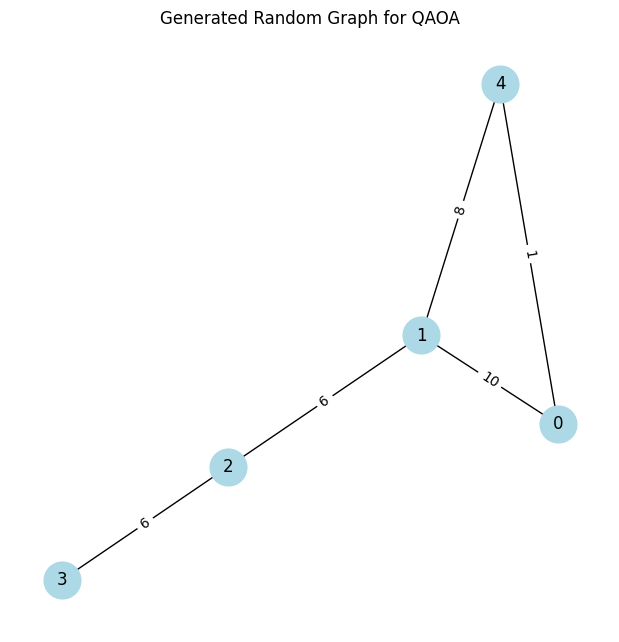

10.0 * ZZIII
+ 1.0 * ZIIIZ
+ 6.0 * IZZII
+ 8.0 * IZIIZ
+ 6.0 * IIZZI
[10, 1, 6, 8, 6] ['ZZIII', 'ZIIIZ', 'IZZII', 'IZIIZ', 'IIZZI']
1


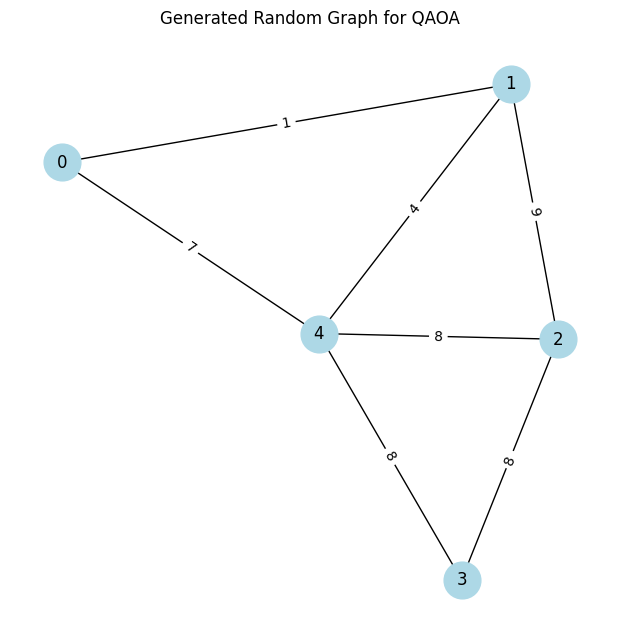

1.0 * ZZIII
+ 7.0 * ZIIIZ
+ 9.0 * IZZII
+ 4.0 * IZIIZ
+ 8.0 * IIZZI
+ 8.0 * IIZIZ
+ 8.0 * IIIZZ
[1, 7, 9, 4, 8, 8, 8] ['ZZIII', 'ZIIIZ', 'IZZII', 'IZIIZ', 'IIZZI', 'IIZIZ', 'IIIZZ']
2


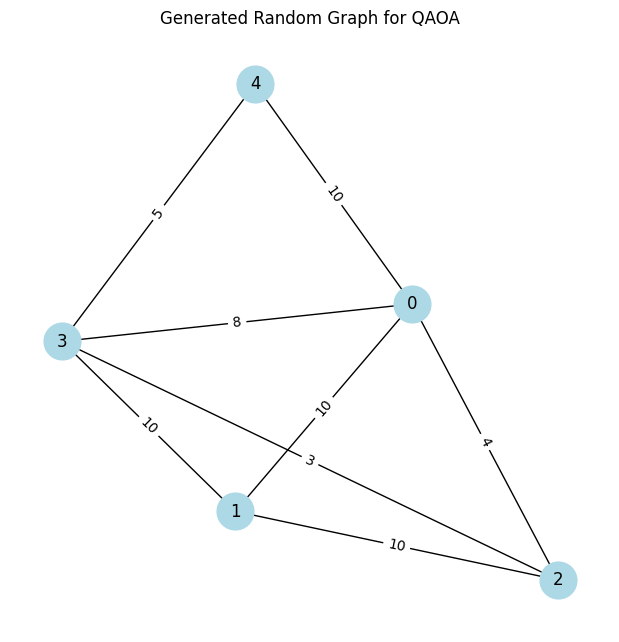

10.0 * ZZIII
+ 4.0 * ZIZII
+ 8.0 * ZIIZI
+ 10.0 * ZIIIZ
+ 10.0 * IZZII
+ 10.0 * IZIZI
+ 3.0 * IIZZI
+ 5.0 * IIIZZ
[10, 4, 8, 10, 10, 10, 3, 5] ['ZZIII', 'ZIZII', 'ZIIZI', 'ZIIIZ', 'IZZII', 'IZIZI', 'IIZZI', 'IIIZZ']
3


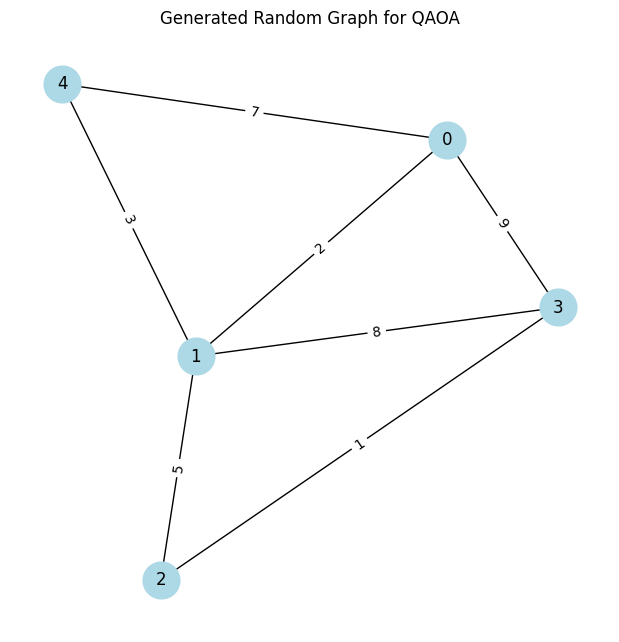

2.0 * ZZIII
+ 9.0 * ZIIZI
+ 7.0 * ZIIIZ
+ 5.0 * IZZII
+ 8.0 * IZIZI
+ 3.0 * IZIIZ
+ 1.0 * IIZZI
[2, 9, 7, 5, 8, 3, 1] ['ZZIII', 'ZIIZI', 'ZIIIZ', 'IZZII', 'IZIZI', 'IZIIZ', 'IIZZI']
4


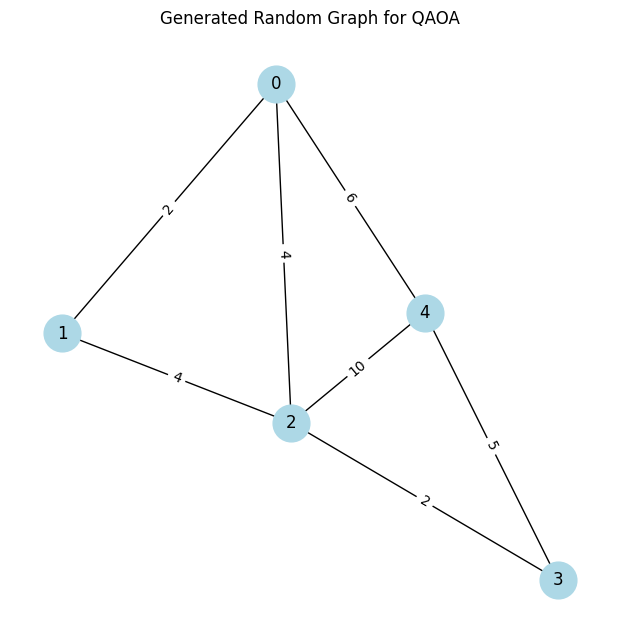

2.0 * ZZIII
+ 4.0 * ZIZII
+ 6.0 * ZIIIZ
+ 4.0 * IZZII
+ 2.0 * IIZZI
+ 10.0 * IIZIZ
+ 5.0 * IIIZZ
[2, 4, 6, 4, 2, 10, 5] ['ZZIII', 'ZIZII', 'ZIIIZ', 'IZZII', 'IIZZI', 'IIZIZ', 'IIIZZ']
5


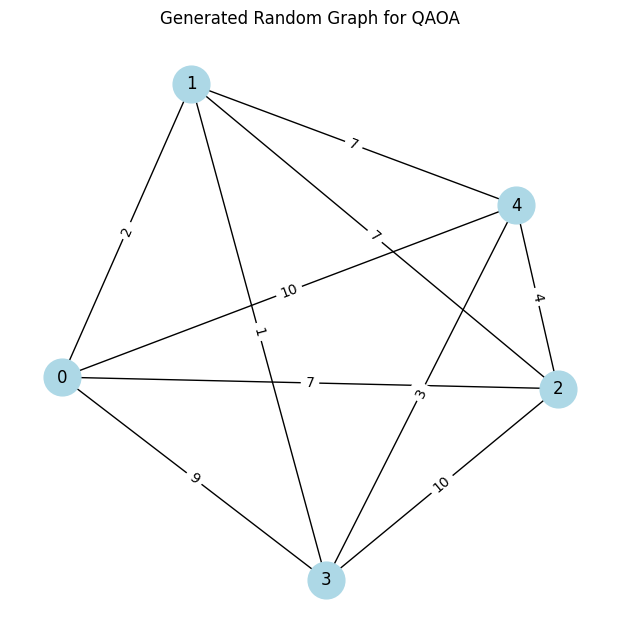

2.0 * ZZIII
+ 7.0 * ZIZII
+ 9.0 * ZIIZI
+ 10.0 * ZIIIZ
+ 7.0 * IZZII
+ 1.0 * IZIZI
+ 7.0 * IZIIZ
+ 10.0 * IIZZI
+ 4.0 * IIZIZ
+ 3.0 * IIIZZ
[2, 7, 9, 10, 7, 1, 7, 10, 4, 3] ['ZZIII', 'ZIZII', 'ZIIZI', 'ZIIIZ', 'IZZII', 'IZIZI', 'IZIIZ', 'IIZZI', 'IIZIZ', 'IIIZZ']
6


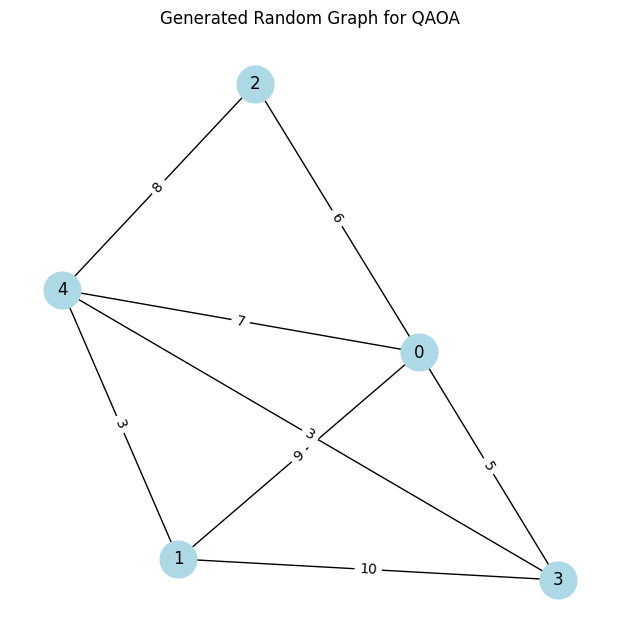

9.0 * ZZIII
+ 6.0 * ZIZII
+ 5.0 * ZIIZI
+ 7.0 * ZIIIZ
+ 10.0 * IZIZI
+ 3.0 * IZIIZ
+ 8.0 * IIZIZ
+ 3.0 * IIIZZ
[9, 6, 5, 7, 10, 3, 8, 3] ['ZZIII', 'ZIZII', 'ZIIZI', 'ZIIIZ', 'IZIZI', 'IZIIZ', 'IIZIZ', 'IIIZZ']
7


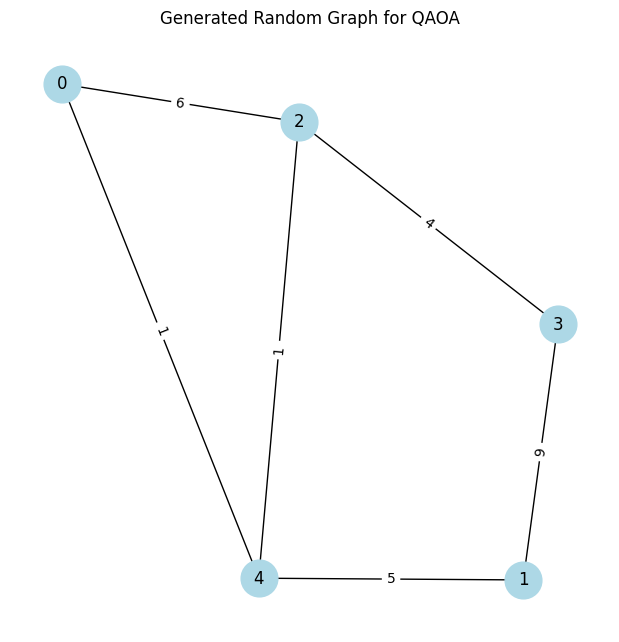

6.0 * ZIZII
+ 1.0 * ZIIIZ
+ 9.0 * IZIZI
+ 5.0 * IZIIZ
+ 4.0 * IIZZI
+ 1.0 * IIZIZ
[6, 1, 9, 5, 4, 1] ['ZIZII', 'ZIIIZ', 'IZIZI', 'IZIIZ', 'IIZZI', 'IIZIZ']


In [ ]:
import random

# Example: Run the two-step QAOA on a random 5-vertex graph with edge probability 0.6 and random weights
for i in range(10):
    print(i)
    PATH = "trial7_saved_graph_"+str(i)
    run_two_step_qaoa(num_vertices=5, edge_prob=(0.5+0.5*random.random()), weighted=True, save_path=PATH)
    
    

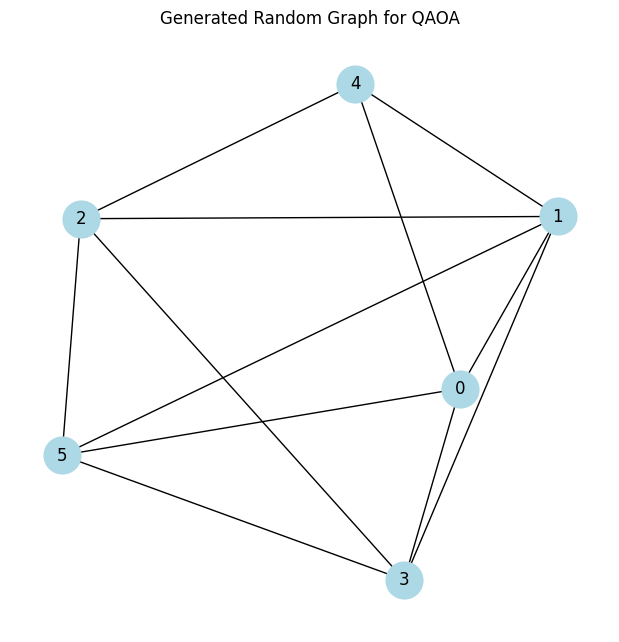

In [ ]:
PATH = "trial3_saved_graph_8"
run_two_step_qaoa(save_path=PATH,repro=1)